In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df=pd.read_csv('upi_data.csv')
df.head()


,Month,No. of Banks live on UPI,Volume (in Mn),Value (in Cr.),Avg_Txn_Value_INR,MoM_Growth_Volume_%,MoM_Growth_Value_%
0,Aug-25,688,20008.31,2485472.91,1242.220,2.776,-? 0.918
1,Jul-25,684,19467.95,2508498.09,1288.527,5.833,? 4.350
2,Jun-25,675,18395.01,2403930.69,1306.838,-1.512,-? 4.390
3,May-25,673,18677.46,2514297.01,1346.166,4.382,? 4.984
4,Apr-25,668,17893.42,2394925.87,1338.439,-2.230,-? 3.322


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     113 non-null    object 
 1   No. of Banks live on UPI  113 non-null    int64  
 2   Volume (in Mn)            113 non-null    float64
 3   Value (in Cr.)            113 non-null    float64
 4   Avg_Txn_Value_INR         113 non-null    float64
 5   MoM_Growth_Volume_%       113 non-null    float64
 6   MoM_Growth_Value_%        113 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 6.3+ KB


In [5]:
df["MoM_Growth_Value_%"] = pd.to_numeric(df["MoM_Growth_Value_%"], errors='coerce')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     113 non-null    object 
 1   No. of Banks live on UPI  113 non-null    int64  
 2   Volume (in Mn)            113 non-null    float64
 3   Value (in Cr.)            113 non-null    float64
 4   Avg_Txn_Value_INR         113 non-null    float64
 5   MoM_Growth_Volume_%       113 non-null    float64
 6   MoM_Growth_Value_%        0 non-null      float64
dtypes: float64(5), int64(1), object(1)
memory usage: 6.3+ KB


In [8]:
df["Month"] = pd.to_datetime(df["Month"], format="%b-%y")
df = df.sort_values("Month")
df.set_index("Month", inplace=True)

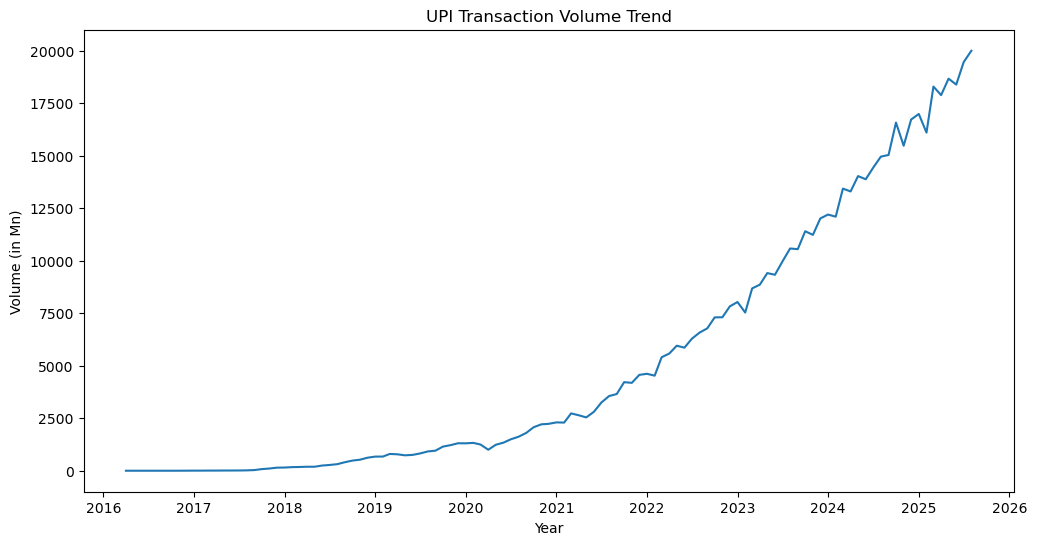

In [11]:
plt.figure(figsize=(12,6))
plt.plot(df["Volume (in Mn)"])
plt.title("UPI Transaction Volume Trend")
plt.xlabel("Year")
plt.ylabel("Volume (in Mn)")
plt.show()

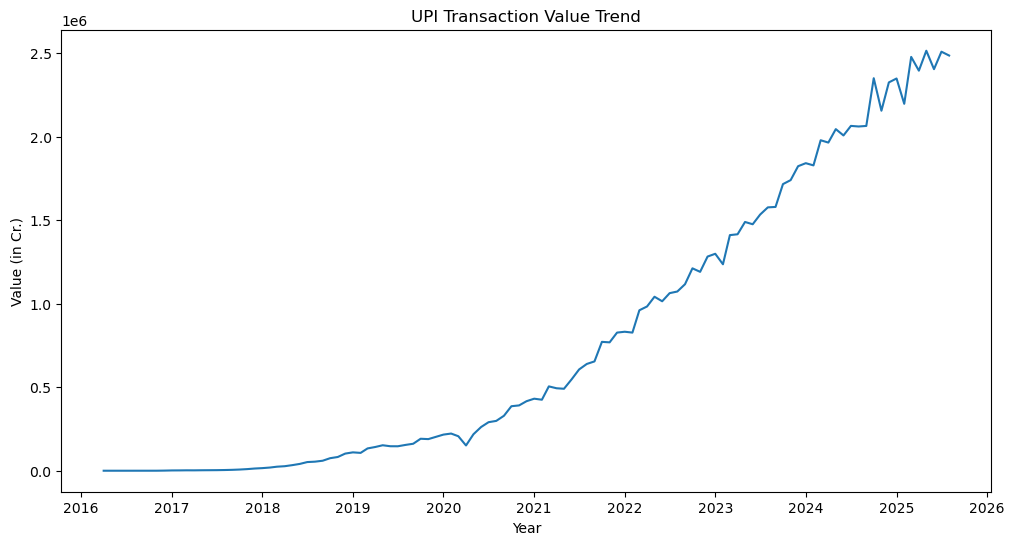

In [12]:
plt.figure(figsize=(12,6))
plt.plot(df["Value (in Cr.)"])
plt.title("UPI Transaction Value Trend")
plt.xlabel("Year")
plt.ylabel("Value (in Cr.)")
plt.show()

In [13]:
yearly_data = df.resample('Y').sum()

yearly_data["YoY_Growth_%"] = yearly_data["Volume (in Mn)"].pct_change() * 100

yearly_data

C:\Users\suraj\AppData\Local\Temp\ipykernel_29120\4135172828.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_data = df.resample('Y').sum()


,No. of Banks live on UPI,Volume (in Mn),Value (in Cr.),Avg_Txn_Value_INR,MoM_Growth_Volume_%,MoM_Growth_Value_%,YoY_Growth_%
Month,,,,,,,
2016-12-31,221,2.65,893.07,15890.797,787.318,0.0,NaN
2017-12-31,626,429.15,57020.87,31039.598,586.150,0.0,16094.339623
2018-12-31,1291,3746.32,585710.45,18215.682,158.469,0.0,772.962834
2019-12-31,1696,10787.54,1836638.18,20644.105,80.140,0.0,187.950309
2020-12-31,2003,18880.89,3387744.72,21337.478,61.513,0.0,75.024983
2021-12-31,2869,38744.55,7159285.80,22255.225,76.857,0.0,105.205104
2022-12-31,4049,74044.48,12595077.87,20537.730,56.819,0.0,91.109408
2023-12-31,5483,117641.09,18292795.21,18732.521,45.336,0.0,58.878947
2024-12-31,7210,172208.01,24682520.78,17247.865,34.979,0.0,46.384235


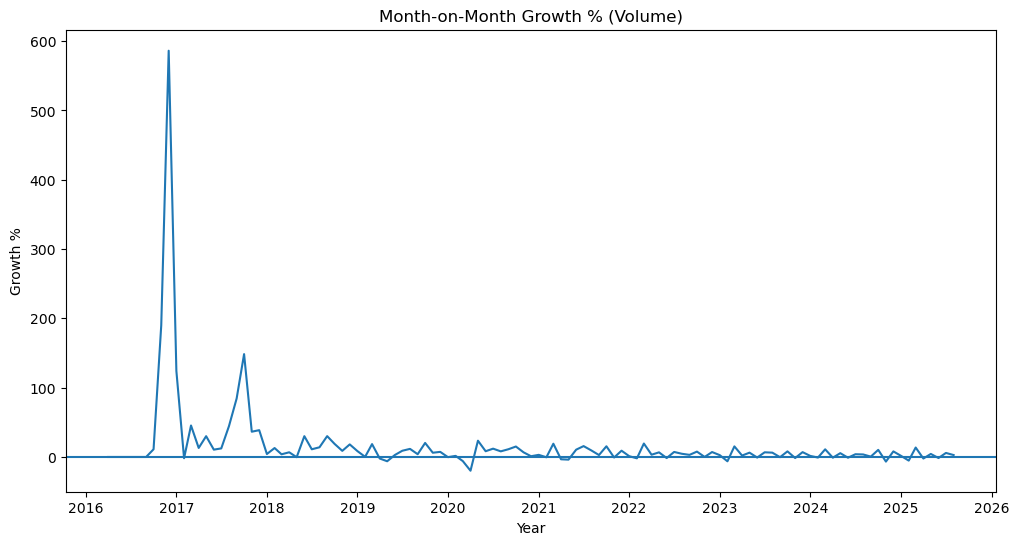

In [14]:
plt.figure(figsize=(12,6))
plt.plot(df["MoM_Growth_Volume_%"])
plt.title("Month-on-Month Growth % (Volume)")
plt.xlabel("Year")
plt.ylabel("Growth %")
plt.axhline(0)
plt.show()

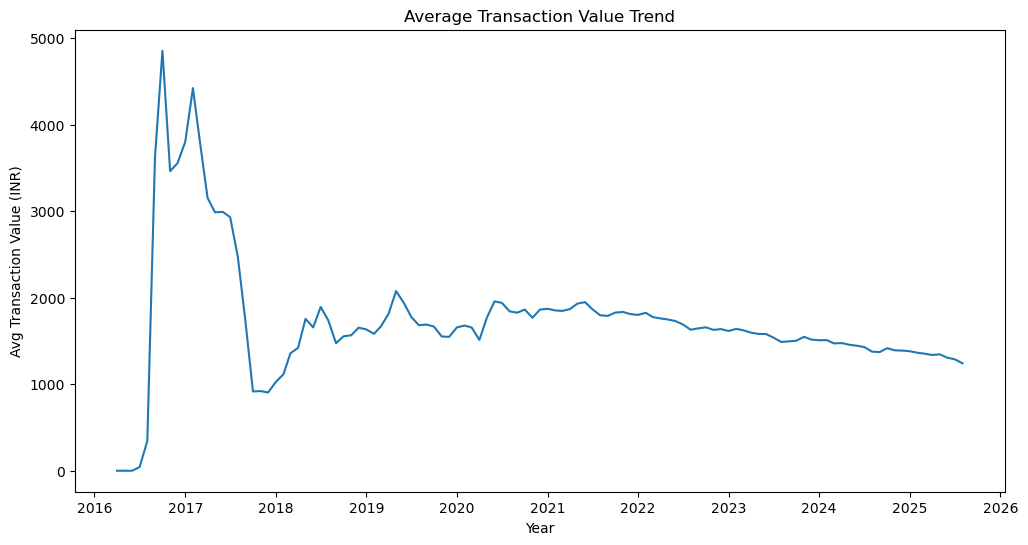

In [15]:
plt.figure(figsize=(12,6))
plt.plot(df["Avg_Txn_Value_INR"])
plt.title("Average Transaction Value Trend")
plt.xlabel("Year")
plt.ylabel("Avg Transaction Value (INR)")
plt.show()

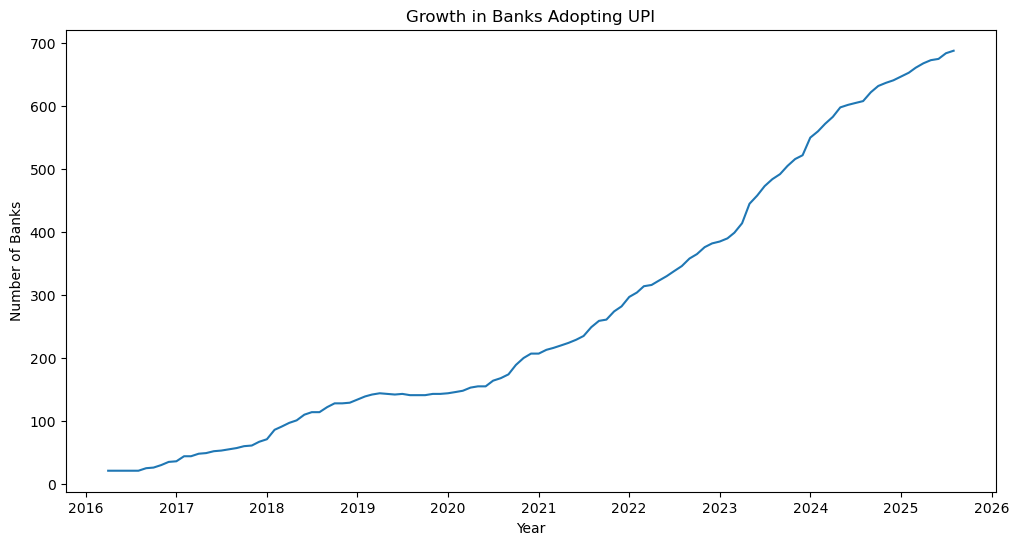

In [16]:
plt.figure(figsize=(12,6))
plt.plot(df["No. of Banks live on UPI"])
plt.title("Growth in Banks Adopting UPI")
plt.xlabel("Year")
plt.ylabel("Number of Banks")
plt.show()

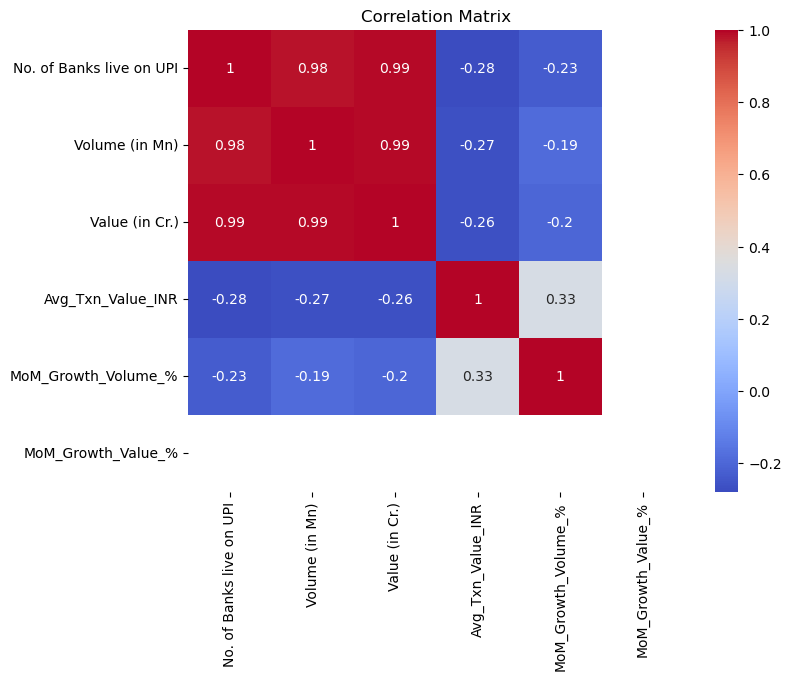

In [17]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

C:\Users\suraj\AppData\Local\Temp\ipykernel_29120\3948338375.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df.resample('Y').sum()


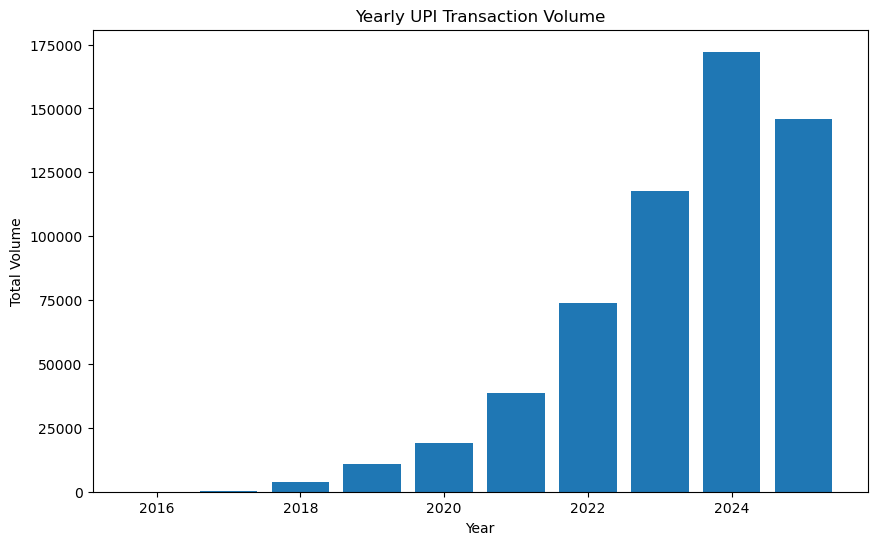

In [18]:
yearly = df.resample('Y').sum()

plt.figure(figsize=(10,6))
plt.bar(yearly.index.year, yearly["Volume (in Mn)"])
plt.title("Yearly UPI Transaction Volume")
plt.xlabel("Year")
plt.ylabel("Total Volume")
plt.show()

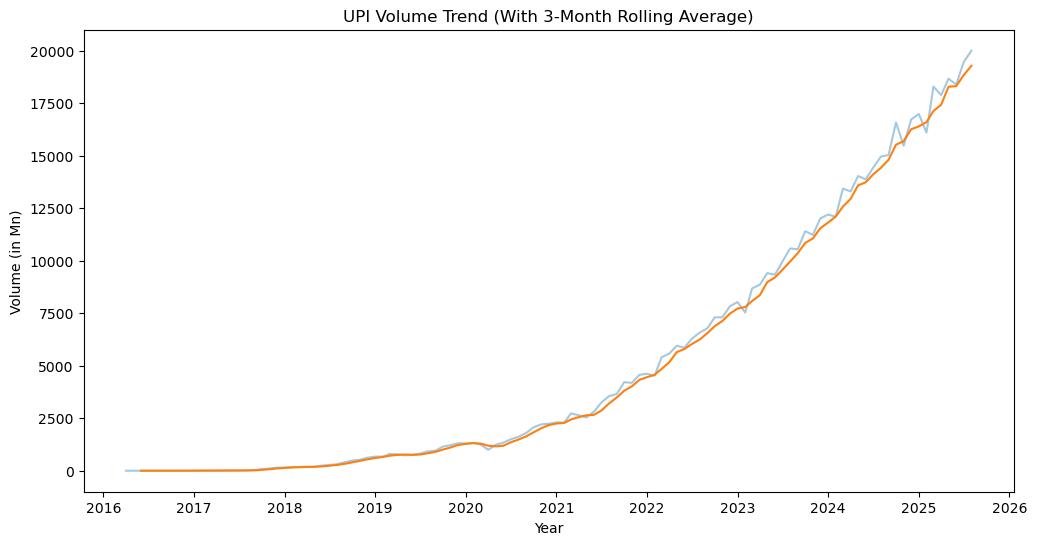

In [19]:
df["Rolling_3M_Volume"] = df["Volume (in Mn)"].rolling(window=3).mean()

plt.figure(figsize=(12,6))
plt.plot(df["Volume (in Mn)"], alpha=0.4)
plt.plot(df["Rolling_3M_Volume"])
plt.title("UPI Volume Trend (With 3-Month Rolling Average)")
plt.xlabel("Year")
plt.ylabel("Volume (in Mn)")
plt.show()

C:\Users\suraj\AppData\Local\Temp\ipykernel_29120\1764629352.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df.resample('Y').sum()


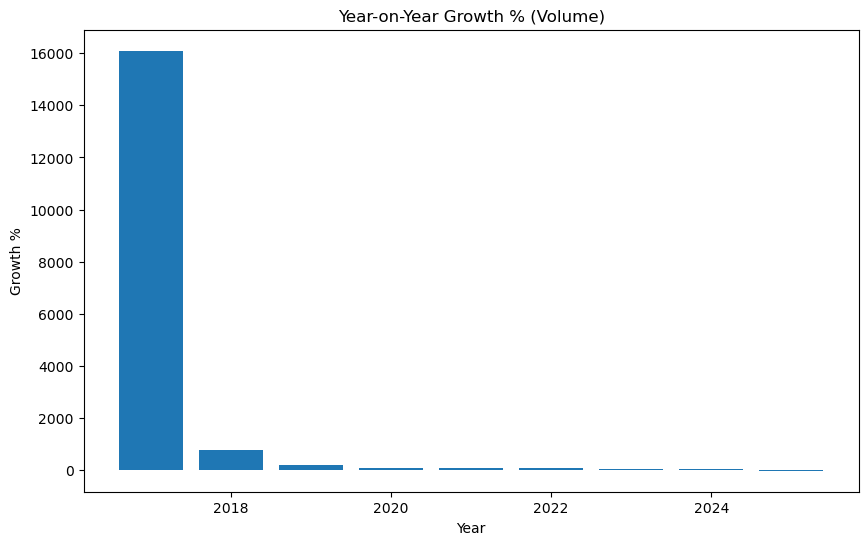

In [20]:
yearly = df.resample('Y').sum()
yearly["YoY_Growth_%"] = yearly["Volume (in Mn)"].pct_change() * 100

plt.figure(figsize=(10,6))
plt.bar(yearly.index.year, yearly["YoY_Growth_%"])
plt.title("Year-on-Year Growth % (Volume)")
plt.xlabel("Year")
plt.ylabel("Growth %")
plt.show()

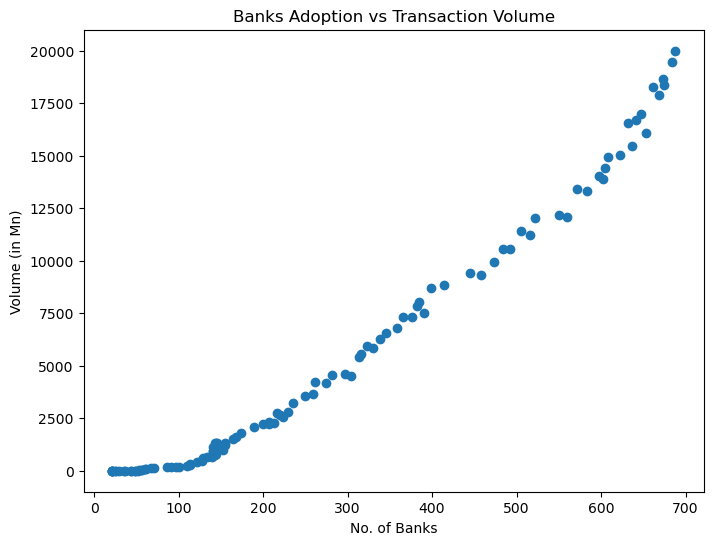

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(df["No. of Banks live on UPI"], df["Volume (in Mn)"])
plt.title("Banks Adoption vs Transaction Volume")
plt.xlabel("No. of Banks")
plt.ylabel("Volume (in Mn)")
plt.show()

In [25]:
early = df["2016":"2018"]["Volume (in Mn)"].mean()
recent = df["2022":"2025"]["Volume (in Mn)"].mean()

print("Average Volume (2016-2018):", early)
print("Average Volume (2022-2025):", recent)

Average Volume (2016-2018): 126.60969696969697
Average Volume (2022-2025): 11584.987045454545


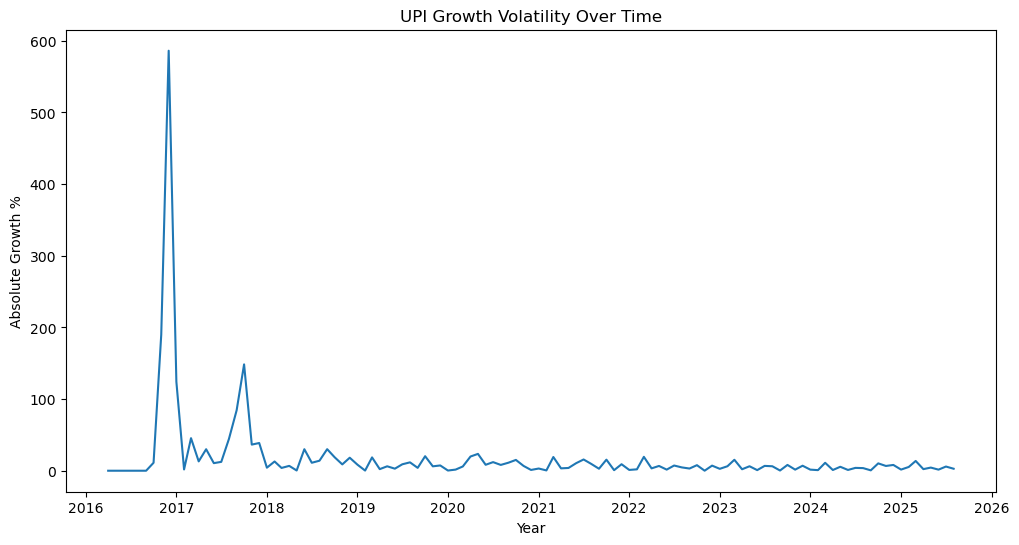

In [26]:
df["Growth_Abs"] = df["MoM_Growth_Volume_%"].abs()

plt.figure(figsize=(12,6))
plt.plot(df["Growth_Abs"])
plt.title("UPI Growth Volatility Over Time")
plt.xlabel("Year")
plt.ylabel("Absolute Growth %")
plt.show()

In [27]:
# Calculate mean and standard deviation
mean_volume = df["Volume (in Mn)"].mean()
std_volume = df["Volume (in Mn)"].std()

# Compute Z-score
df["Z_score"] = (df["Volume (in Mn)"] - mean_volume) / std_volume

In [28]:
df["Anomaly"] = df["Z_score"].abs() > 2

df[df["Anomaly"] == True]

,No. of Banks live on UPI,Volume (in Mn),Value (in Cr.),Avg_Txn_Value_INR,MoM_Growth_Volume_%,MoM_Growth_Value_%,Rolling_3M_Volume,Volume_Normalized,Value_Normalized,Volume_norm,Value_norm,Banks_norm,Growth_Abs,Z_score,Anomaly
Month,,,,,,,,,,,,,,,
2025-03-01,661,18301.51,2477221.61,1353.561,13.630,NaN,17134.566667,0.914695,0.985254,0.914695,0.985254,0.959520,13.630,2.204493,True
2025-04-01,668,17893.42,2394925.87,1338.439,-2.230,NaN,17433.706667,0.894299,0.952523,0.894299,0.952523,0.970015,2.230,2.136071,True
2025-05-01,673,18677.46,2514297.01,1346.166,4.382,NaN,18290.796667,0.933485,1.000000,0.933485,1.000000,0.977511,4.382,2.267527,True
2025-06-01,675,18395.01,2403930.69,1306.838,-1.512,NaN,18321.963333,0.919369,0.956105,0.919369,0.956105,0.980510,1.512,2.220170,True
2025-07-01,684,19467.95,2508498.09,1288.527,5.833,NaN,18846.806667,0.972993,0.997694,0.972993,0.997694,0.994003,5.833,2.400065,True
2025-08-01,688,20008.31,2485472.91,1242.220,2.776,NaN,19290.423333,1.000000,0.988536,1.000000,0.988536,1.000000,2.776,2.490665,True


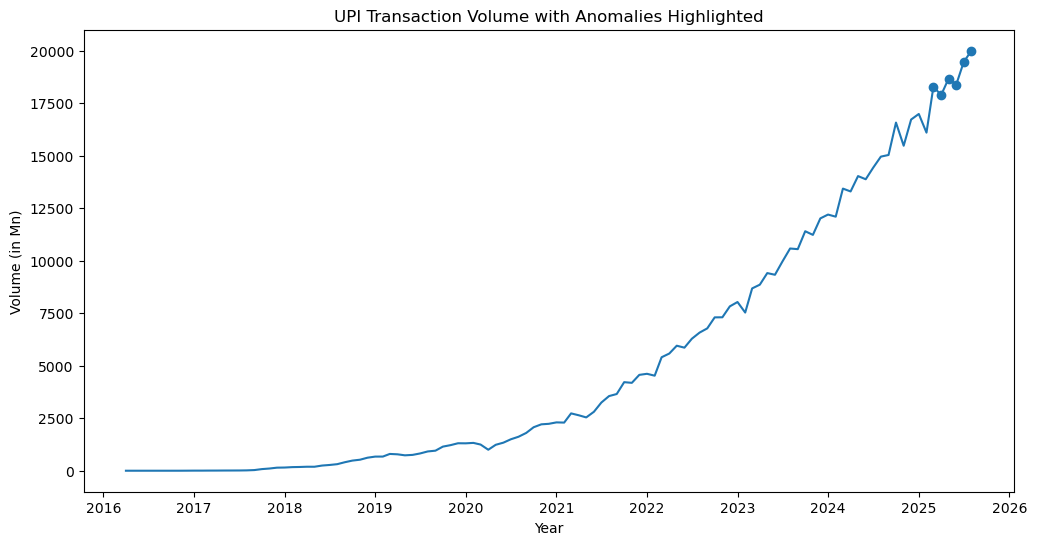

In [29]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Volume (in Mn)"])
plt.scatter(df[df["Anomaly"]].index,
            df[df["Anomaly"]]["Volume (in Mn)"])

plt.title("UPI Transaction Volume with Anomalies Highlighted")
plt.xlabel("Year")
plt.ylabel("Volume (in Mn)")
plt.show()